In [2]:
import numpy as np

# Set a random seed for consistency
np.random.seed(0)

# Number of training examples
m = 100  

# Generate two feature variables (X1, X2) randomly
X = 2 * np.random.rand(m, 2)  

# output variable y with known linear relationship + noise
# bias is 4
# x_1 is multiplied by 3
# x_2 is multiplied by 5
# and some noise dropped in too
y = 4 + 3 * X[:, 0] + 5 * X[:, 1] + np.random.randn(m)

# Add an intercept column of ones to X
X_b = np.c_[np.ones((m, 1)), X]  # Adds a column of ones for theta_0

# Print statements for clarity
print(f"First 5 rows of feature matrix X:\n{X[:5]}")
print(f"First 5 values of output y:\n{y[:5]}")
print(f"First 5 rows of feature matrix with intercept X_b:\n{X_b[:5]}")


First 5 rows of feature matrix X:
[[1.09762701 1.43037873]
 [1.20552675 1.08976637]
 [0.8473096  1.29178823]
 [0.87517442 1.783546  ]
 [1.92732552 0.76688304]]
First 5 values of output y:
[15.57141061 11.98548058 11.85340127 15.10543323 13.1183593 ]
First 5 rows of feature matrix with intercept X_b:
[[1.         1.09762701 1.43037873]
 [1.         1.20552675 1.08976637]
 [1.         0.8473096  1.29178823]
 [1.         0.87517442 1.783546  ]
 [1.         1.92732552 0.76688304]]


In [3]:
# Compute theta using the Normal Equation
# θ = (X^T X)^(-1) X^T y
theta_normal_eq = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Print results
print(f"Computed theta values using the Normal Equation:\n{theta_normal_eq}")

Computed theta values using the Normal Equation:
[4.11450326 2.78685022 5.01478753]


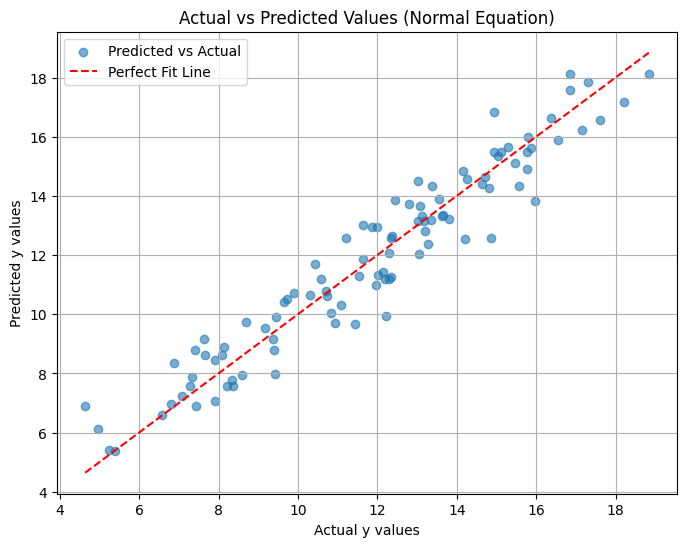

In [6]:
import matplotlib.pyplot as plt

# Predict y using our computed theta
# noise will be seen as the distance from the dotted line
y_pred = X_b.dot(theta_normal_eq)

# Scatter plot of actual vs. predicted values

# how big the plot is (8" wide by 6" tall)
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.6, label="Predicted vs Actual")
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", linestyle="--", label="Perfect Fit Line")
plt.xlabel("Actual y values")
plt.ylabel("Predicted y values")
plt.title("Actual vs Predicted Values (Normal Equation)")
plt.legend()
plt.grid(True)
plt.show()


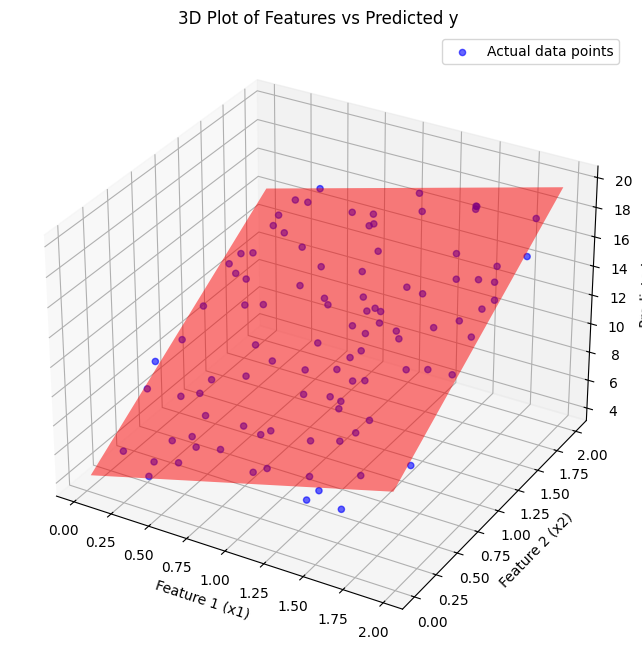

In [7]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D plot to visualize the relationship between the features and predicted output
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual data points
ax.scatter(X[:, 0], X[:, 1], y, color="blue", label="Actual data points", alpha=0.6)

# Create a meshgrid for the surface
x1_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
x2_vals = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
x1_grid, x2_grid = np.meshgrid(x1_vals, x2_vals)

# Calculate the predicted y values (regression plane)
y_grid = theta_normal_eq[0] + theta_normal_eq[1] * x1_grid + theta_normal_eq[2] * x2_grid

# Plot the surface (regression plane)
ax.plot_surface(x1_grid, x2_grid, y_grid, color='red', alpha=0.5, rstride=100, cstride=100)

# Labels and title
ax.set_xlabel('Feature 1 (x1)')
ax.set_ylabel('Feature 2 (x2)')
ax.set_zlabel('Predicted y')
ax.set_title('3D Plot of Features vs Predicted y')

# Show the legend
ax.legend()

# Show the plot
plt.show()


In [9]:
# Mean Squared Error (MSE) calculation
# MSE = (1/m) * Σ(y_pred(i) - y(i))^2
mse_normal_eq = np.mean((y_pred - y) ** 2)

# Print the result
print(f"Mean Squared Error (MSE) for Normal Equation model: {mse_normal_eq:.4f}")


Mean Squared Error (MSE) for Normal Equation model: 0.8459


In [10]:
# Mean Absolute Error (MAE) calculation
# MAE = (1/m) * Σ|y_pred(i) - y(i)|
mae_normal_eq = np.mean(np.abs(y_pred - y))

# Print the result
print(f"Mean Absolute Error (MAE) for Normal Equation model: {mae_normal_eq:.4f}")


Mean Absolute Error (MAE) for Normal Equation model: 0.7480


In [11]:
# R-squared (R²) calculation (higher value indicates better fit)
# R² = 1 - (Σ(y_pred(i) - y(i))^2 / Σ(y(i) - y_mean)^2)
ss_total = np.sum((y - np.mean(y)) ** 2)  # Total sum of squares
ss_residual = np.sum((y_pred - y) ** 2)  # Residual sum of squares
r2_normal_eq = 1 - (ss_residual / ss_total)

# Print the result
print(f"R-squared (R²) for Normal Equation model: {r2_normal_eq:.4f}")


R-squared (R²) for Normal Equation model: 0.9224


In [13]:
# One-off prediction for a new input
# Assume you have new feature values x_1 = 25 and x_2 = 37
x_new = np.array([25, 37])

# Add the bias term (theta_0) to the feature vector by adding a 1 to the front
x_new_biased = np.concatenate([[1], x_new])  # Add bias term, shape (3,)

# Make the prediction using the normal equation model (theta is already computed)
y_pred_new = np.dot(x_new_biased, theta_normal_eq)

# Print the result
print(f"Predicted y value for x_1 = {x_new[0]} and x_2 = {x_new[1]}: {y_pred_new:.4f}")


Predicted y value for x_1 = 25 and x_2 = 37: 259.3329


In [17]:
# alternately, just do it by hand :)

# Given values
theta_0 = theta_normal_eq[0]
theta_1 = theta_normal_eq[1]
theta_2 = theta_normal_eq[2]

# Input values
x_1 = 25
x_2 = 37

# Calculate the prediction
y_pred = theta_0 + (theta_1 * x_1) + (theta_2 * x_2)
print(y_pred)


259.3328974467617
